# Point-Based Image Repainting Demo

This notebook demonstrates how to perform **image-only repainting/inpainting** on custom regions of an image defined by point coordinates and radii.
It uses the **FLUX Fill** inpainting model (without SAM2 or video processing).

**Workflow:**
1. Configure path settings, prompt, points, and radii.
2. Load, resize, and visualize the points and affected regions.
3. Load the FLUX model on CUDA.
4. Run inpainting and visualize the results.

In [1]:
# 1. Imports and project paths
import gc
import os
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
from PIL import Image

# Setup paths relative to the project root
cwd = Path.cwd().resolve()
if (cwd / "app" / "utils.py").is_file():
    PROJECT_ROOT = cwd
elif (cwd / "utils.py").is_file() and cwd.name == "app":
    PROJECT_ROOT = cwd.parent
else:
    raise RuntimeError("Launch this notebook from the VideoPainter project root or its app/ directory.")

APP_DIR = PROJECT_ROOT / "app"
if str(APP_DIR) not in sys.path:
    sys.path.insert(0, str(APP_DIR))

# Change directory to APP_DIR for relative utility paths
os.chdir(APP_DIR)
OUTPUT_DIR = APP_DIR / "notebook_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Working directory: {Path.cwd()}")

Project root: /workspace/VideoPainter
Working directory: /workspace/VideoPainter/app


## Configuration

Set the image path, the prompt to describe the target inpainted content, coordinates for the region center(s), and the radius for each circle. Coordinates are relative to the resized resolution (default: 720x480).

In [ ]:
# 2. User configuration

# Input Image (relative to app/ or absolute path)
# IMAGE_PATH = PROJECT_ROOT / "assets/teaser.jpg"
IMAGE_PATH = PROJECT_ROOT / "app/photo.jpg"

# Manual points (x, y) coordinates on the resized image (720x480)
# Use the visualization cell below to verify and adjust these coordinates.
POINTS = [
    (240, 300), # Center point
]

# Radius around each point to repaint (in pixels)
# Can be a single integer/float (applies to all points), or a list of radii matching the points list.
RADIUS = 60

# Model Paths
IMAGE_INPAINTING_MODEL_PATH = PROJECT_ROOT / "ckpt/flux_inp"

# Output resolution (resize dimensions)
FRAME_WIDTH = 480
FRAME_HEIGHT = 720

In [16]:
# 3. Validation and helper functions

def validate_configuration():
    if not Path(IMAGE_PATH).exists():
        raise FileNotFoundError(f"Input image not found: {IMAGE_PATH}")
    if not Path(IMAGE_INPAINTING_MODEL_PATH).exists():
        raise FileNotFoundError(f"FLUX model checkpoint not found: {IMAGE_INPAINTING_MODEL_PATH}")
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is not available. A GPU is required for FLUX inference.")
    if not POINTS:
        raise ValueError("Please provide at least one coordinate in POINTS.")
    print("Configuration validation passed.")

def create_circle_mask(width, height, points, radii):
    """Draw white circles on a black background to define inpainting regions."""
    mask_np = np.zeros((height, width), dtype=np.uint8)
    
    # Standardize radii to a list
    if not isinstance(radii, (list, tuple)):
        radii = [radii] * len(points)
        
    if len(radii) != len(points):
        raise ValueError("If RADIUS is a list, its length must match the number of POINTS.")
        
    for idx, (x, y) in enumerate(points):
        r = radii[idx]
        # Validate point coordinates are within bounds
        if not (0 <= x < width and 0 <= y < height):
            print(f"Warning: Point {idx} ({x}, {y}) is outside image boundaries ({width}x{height})")
        # Draw filled circle (thickness = -1)
        cv2.circle(mask_np, (int(x), int(y)), int(r), 255, -1)
        
    # Return as RGB PIL Image matching diffusers expected format
    return Image.fromarray(mask_np).convert("RGB")

validate_configuration()

Configuration validation passed.


## Visual Verification

Run the cell below to load the image and display it with red circle overlays showing the target regions. You can refine coordinates in the configuration cell above and rerun this cell until the region aligns properly.

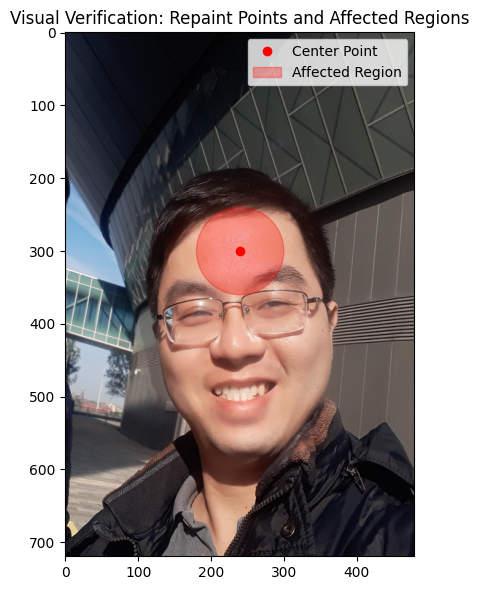

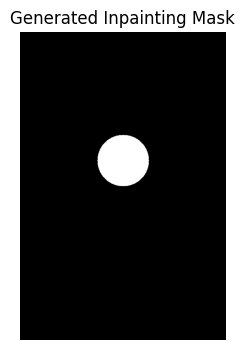

In [17]:
# 4. Load, resize, and visualize configuration

# Load input image
original_img = Image.open(IMAGE_PATH).convert("RGB")
# Resize input image to configured size
resized_img = original_img.resize((FRAME_WIDTH, FRAME_HEIGHT), Image.Resampling.LANCZOS)

# Create mask based on configured points and radius
mask_img = create_circle_mask(FRAME_WIDTH, FRAME_HEIGHT, POINTS, RADIUS)

# Plot input image with point overlay and circular regions for verification
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(resized_img)

# Convert single radius to list if needed for drawing
drawing_radii = RADIUS if isinstance(RADIUS, (list, tuple)) else [RADIUS] * len(POINTS)

for idx, (x, y) in enumerate(POINTS):
    r = drawing_radii[idx]
    # Draw point center
    ax.plot(x, y, 'ro', markersize=6, label='Center Point' if idx == 0 else "")
    # Draw transparent circle representing the inpaint region
    circle = patches.Circle((x, y), r, color='red', fill=True, alpha=0.3, label='Affected Region' if idx == 0 else "")
    ax.add_patch(circle)

plt.title("Visual Verification: Repaint Points and Affected Regions")
plt.axis("on") # Keeps axes coordinates visible so users can easily find pixel values
plt.legend()
plt.tight_layout()
plt.show()

# Verify the binary mask itself
fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(mask_img, cmap='gray')
plt.title("Generated Inpainting Mask")
plt.axis("off")
plt.show()

## Load FLUX and Run Repainting

This cell loads the image-inpainting model (FLUX Fill), runs inference on the visual verified image and mask, and displays a side-by-side comparison of the original and the final output.

In [22]:
# 5. Load FLUX Fill and run inpainting

# Cleanup VRAM before loading model
gc.collect()
torch.cuda.empty_cache()

# Load FLUX Fill pipeline
import utils as videopainter_utils
from importlib import reload
videopainter_utils = reload(videopainter_utils)

offload = CPU_OFFLOAD_MODE == "on"
print("Loading FLUX Fill model...")
pipe = videopainter_utils.load_flux_model(
    img_inpainting_model=str(IMAGE_INPAINTING_MODEL_PATH),
    device="cuda",
    dtype=torch.float16,
    cpu_offload=offload,
)
print("FLUX Fill loaded successfully.")

Loading FLUX Fill model...


Loading pipeline components...: 100%|██████████| 7/7 [00:31<00:00,  4.52s/it]


FLUX Fill loaded successfully.


Generating inpainted image...


 28%|██▊       | 14/50 [00:03<00:08,  4.34it/s]

100%|██████████| 50/50 [00:11<00:00,  4.34it/s]


Inpainting generation finished.


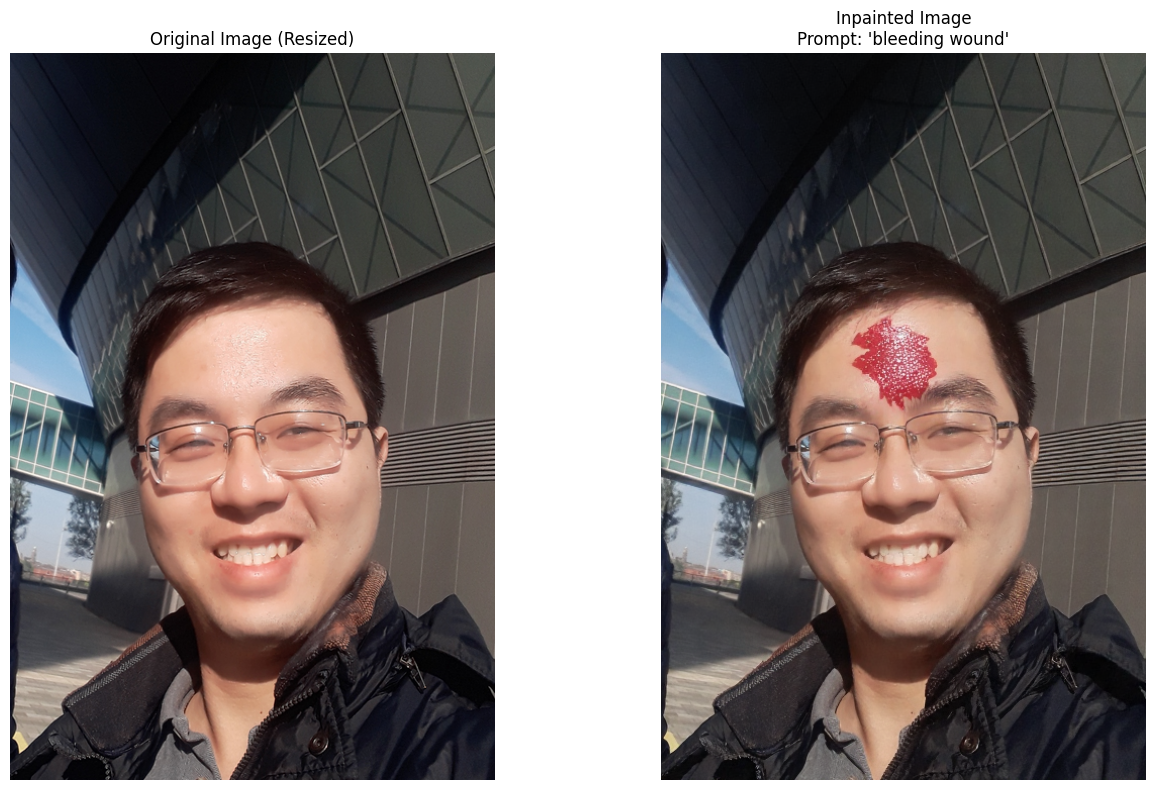

Saved inpainted result to: /workspace/VideoPainter/app/notebook_outputs/photo_inpainted.png


In [ ]:
# Generation options
SEED = 42
CFG_SCALE = 30.0 # Standard guidance scale for FLUX Fill
NUM_STEPS = 100

# CPU offload option to save VRAM ("on", "off", "auto")
CPU_OFFLOAD_MODE = "off"

# Target description of what should be placed in the mask region
TEXT_PROMPT = "bleeding cut"

# Run inference
print("Generating inpainted image...")
# generator = torch.Generator("cpu").manual_seed(SEED)
generator = None
result_img = pipe(
    prompt=TEXT_PROMPT,
    image=resized_img,
    mask_image=mask_img,
    height=FRAME_HEIGHT,
    width=FRAME_WIDTH,
    guidance_scale=CFG_SCALE,
    num_inference_steps=NUM_STEPS,
    max_sequence_length=512,
    generator=generator,
).images[0]

print("Inpainting generation finished.")

# Show side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].imshow(resized_img)
axes[0].set_title("Original Image (Resized)")
axes[0].axis("off")

axes[1].imshow(result_img)
axes[1].set_title(f"Inpainted Image\nPrompt: '{TEXT_PROMPT}'")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Save final result
output_path = OUTPUT_DIR / f"{Path(IMAGE_PATH).stem}_inpainted.png"
result_img.save(output_path)
print(f"Saved inpainted result to: {output_path}")



In [ ]:
# Cleanup model from memory
del pipe
gc.collect()
torch.cuda.empty_cache()